## Bearing Fault Classification using Machine Learning and Vibration Signal Analysis

### Objective

To analyze vibration signal data from the CWRU bearing dataset using NumPy, Pandas, and Machine Learning techniques to identify different bearing fault conditions such as inner race faults, ball faults, and outer race faults.

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import random
import zipfile

from scipy.stats import kurtosis,skew

from sklearn.model_selection import(
    train_test_split,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import joblib

### Load Dataset

In [2]:
or12=pd.read_csv("OR007@12_3.csv",header=None)
or6=pd.read_csv("OR007@6_3.csv",header=None)
or3=pd.read_csv("OR007@3_3.csv",header=None)
ir=pd.read_csv("IR007_3.csv",header=None)
ball=pd.read_csv("B007_3.csv",header=None)

### Assign Column Names

In [3]:
data=[or12, or6, or3, ir, ball]
for df in data:
    df.columns = ["signal"]

### Add Labels to Each Dataset

In [4]:
or12["label"]="OR@12"
or6["label"]="OR@6"
or3["label"]="OR@3"
ir["label"]="inner_race"
ball["label"]="ball_fault"

### Combine All Datasets

In [5]:
data=pd.concat(
    [or12,or6,or3,ir,ball],
    ignore_index=True
)
print(data.head())
data.to_csv(
    "combined_bearing_dataset.csv",
    index=False
)
print("CSV file created successfully!")

     signal  label
0  0.167101  OR@12
1  0.159591  OR@12
2  0.128507  OR@12
3  0.076562  OR@12
4  0.023782  OR@12
CSV file created successfully!


### Check Dataset Information

In [6]:
print(data.info())
print(data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2432859 entries, 0 to 2432858
Data columns (total 2 columns):
 #   Column  Dtype  
---  ------  -----  
 0   signal  float64
 1   label   str    
dtypes: float64(1), str(1)
memory usage: 52.7 MB
None
             signal
count  2.432859e+06
mean   1.295824e-02
std    5.230324e-01
min   -5.287613e+00
25%   -1.451963e-01
50%    1.314277e-02
75%    1.723163e-01
max    5.385269e+00


### Part 1 : Outlier Detection and Clipping

#### Find Outliers using IQR Method

In [7]:
Q1=data["signal"].quantile(0.25)
Q3=data["signal"].quantile(0.75)
IQR=Q3-Q1
l_bound=Q1-1.5*IQR
u_bound=Q3+1.5*IQR
print("Lower Bound:",l_bound)
print("Upper Bound:",u_bound)

Lower Bound: -0.6214652307692321
Upper Bound: 0.648585230769232


#### Outlier Clipping

In [8]:
data["signal"]=np.clip(data["signal"],l_bound,u_bound)
print(data.head())

     signal  label
0  0.167101  OR@12
1  0.159591  OR@12
2  0.128507  OR@12
3  0.076562  OR@12
4  0.023782  OR@12


### Part 2 : Signal Windowing

#### Divide Long Signal into Smaller Windows

In [9]:
window_size=1000
features=[]
labels=[]

### Part 3 : Feature Extraction

In this step:
- Statistical vibration features are extracted from signal windows
- Input features (X) and target labels (y) are created
- Important vibration characteristics are prepared for classification

#### Extract Statistical Features

In [10]:
for label in data["label"].unique():
    signal=data[data["label"]==label]["signal"].values
    for i in range(0,len(signal)-window_size,100):
        window=signal[i:i+window_size]
        mean=np.mean(window)
        std=np.std(window)
        rms=np.sqrt(np.mean(window**2))
        maxi=np.max(window)
        mini=np.min(window)
        kurt=kurtosis(window)
        sk=skew(window)
        features.append([mean,std,rms,maxi,mini,kurt,sk])
        labels.append(label)

#### Create Feature Dataset

In [11]:
feature_names=["mean","std","rms","max","min","kurtosis","skewness"]
X=pd.DataFrame(
    features,
    columns=feature_names
)
y=np.array(labels)
print("Shape of X:",X.shape)
print("Shape of y:",y.shape)

Shape of X: (24281, 7)
Shape of y: (24281,)


### Part 4 : Train Test Split

The dataset is divided into training and testing sets for model training and evaluation.

In [12]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
) 

print("Training Data Shape:", X_train.shape) 
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (19424, 7)
Testing Data Shape: (4857, 7)


### Part 5 : Feature Scaling

In [13]:
scaler=StandardScaler()
X_train=pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)
X_test=pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

You must also save the scaler because the dashboard needs to scale new data exactly like the training data.

In [14]:
joblib.dump(scaler,"scaler.pkl")
print("Scaler saved successfully!")

Scaler saved successfully!


### Part 6 : Model Training

#### Random Forest Classifier

A Random Forest model is trained using controlled depth and split parameters to reduce overfitting.

In [15]:
model=RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train,y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
import joblib

joblib.dump(
    model,
    "random_forest_model.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


#### KNN Classifier

In [17]:
knn_model=KNeighborsClassifier(
    n_neighbors=5,
    weights='uniform',
    metric='minkowski'
)

knn_model.fit(X_train,y_train)

print("KNN model trained successfully!")

KNN model trained successfully!


In [18]:
import joblib

joblib.dump(
    knn_model,
    "knn_model.pkl"
)

print("KNN model saved successfully!")

KNN model saved successfully!


### Part 7 : Model Evaluation

The model is evaluated using:
- Accuracy
- Confusion Matrix
- Classification Report

##### Random Forest Model Evaluation

In [19]:
y_pred=model.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy :",accuracy*100)

Accuracy : 93.69981470043237


In [20]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[781   3   0  40 143]
 [  4 956  11   0   0]
 [  0  68 906   0   0]
 [ 25   0   0 950   0]
 [ 12   0   0   0 958]]


In [21]:
print("\nClassification Report:\n",classification_report(y_test,y_pred))


Classification Report:
               precision    recall  f1-score   support

       OR@12       0.95      0.81      0.87       967
        OR@3       0.93      0.98      0.96       971
        OR@6       0.99      0.93      0.96       974
  ball_fault       0.96      0.97      0.97       975
  inner_race       0.87      0.99      0.93       970

    accuracy                           0.94      4857
   macro avg       0.94      0.94      0.94      4857
weighted avg       0.94      0.94      0.94      4857



#### Visualization of Confusion Matrix

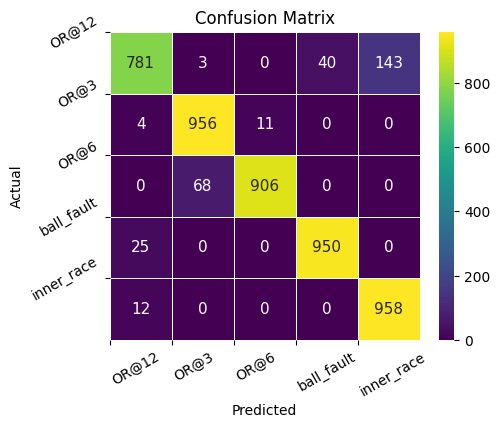

In [22]:
import seaborn as sns
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    linewidths=0.60,
    linecolor='white',
    cbar=True,
    annot_kws={"size":11, "weight":"normal"}
)

plt.xticks(
    range(len(np.unique(y))),
    np.unique(y),
    rotation=30,
    ha='left'
)

plt.yticks(
    range(len(np.unique(y))),
    np.unique(y),
    rotation=30
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

##### KNN Model Evaluation

In [23]:
y_knn_pred=knn_model.predict(X_test)

In [24]:
knn_accuracy=accuracy_score(y_test,y_knn_pred)
print("Accuracy :",knn_accuracy*100)

Accuracy : 95.16162240065884


In [25]:
knn_cm=confusion_matrix(y_test,y_knn_pred)
print(knn_cm)

[[835   0   0  41  91]
 [  0 957  14   0   0]
 [  0  32 942   0   0]
 [ 19   0   0 956   0]
 [ 38   0   0   0 932]]


In [26]:
print("\nClassification Report:\n",classification_report(y_test,y_knn_pred))


Classification Report:
               precision    recall  f1-score   support

       OR@12       0.94      0.86      0.90       967
        OR@3       0.97      0.99      0.98       971
        OR@6       0.99      0.97      0.98       974
  ball_fault       0.96      0.98      0.97       975
  inner_race       0.91      0.96      0.94       970

    accuracy                           0.95      4857
   macro avg       0.95      0.95      0.95      4857
weighted avg       0.95      0.95      0.95      4857



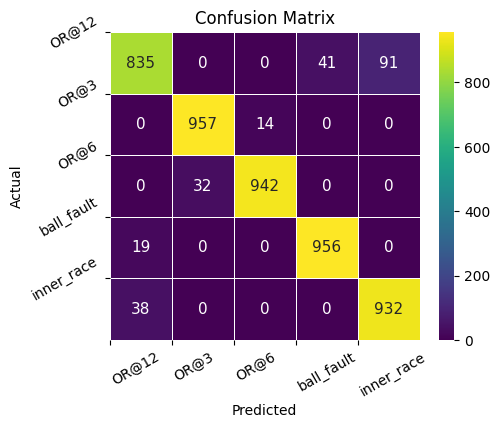

In [27]:
import seaborn as sns
plt.figure(figsize=(5,4))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    linewidths=0.60,
    linecolor='white',
    cbar=True,
    annot_kws={"size":11, "weight":"normal"}
)

plt.xticks(
    range(len(np.unique(y))),
    np.unique(y),
    rotation=30,
    ha='left'
)

plt.yticks(
    range(len(np.unique(y))),
    np.unique(y),
    rotation=30
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Part 8 : Cross Validation and Feature Importance

Cross validation is used to reduce overfitting and evaluate model generalization.

In [28]:
rf_scores=cross_val_score(model,X,y,cv=5) 
print("Random Forest CV Scores :",rf_scores) 
print("Mean Accuracy :",rf_scores.mean())

Random Forest CV Scores : [0.91867408 0.92977759 0.9324547  0.92174629 0.93389621]
Mean Accuracy : 0.9273097745437129


In [29]:
knn_scores=cross_val_score(knn_model,X,y,cv=5)
print("KNN CV Scores :",knn_scores)
print("Mean Accuracy :",knn_scores.mean())

KNN CV Scores : [0.93761581 0.94172158 0.95551895 0.93657331 0.94378089]
Mean Accuracy : 0.9430421080802212


### Part 9 : Feature Importance Analysis

The importance of each vibration feature is analyzed using Random Forest.

In [30]:
importance = model.feature_importances_
for name,score in zip(feature_names,importance):
    print(name,":",score)

mean : 0.03258842635845637
std : 0.34057579203204363
rms : 0.26931027102710275
max : 0.08177533519874425
min : 0.10445053856831883
kurtosis : 0.12094628258745396
skewness : 0.05035335422788007


### Part 10 : Prediction

A new vibration feature sample is given to the trained model for fault prediction.

In [45]:
all_predictions = {}
answer_key=pd.read_csv("hidden_answer_key.csv")
for file_num in range(1,6):
    print("\n" + "="*50)
    print(f"TEST FILE {file_num}")
    print("="*50)
    test_signal=pd.read_csv(
        f"test_file_{file_num}.csv"
    )
    signal=test_signal["signal"].values
    window_size=1000
    predictions=[]
    # Window-wise prediction
    for i in range(0,len(signal),window_size):
        window=signal[i:i+window_size]
        # Skip incomplete windows
        if len(window)<window_size:
            continue
        # Feature extraction
        mean=np.mean(window)
        std=np.std(window)
        rms=np.sqrt(np.mean(window**2))
        maxi=np.max(window)
        mini=np.min(window)
        kurt=kurtosis(window)
        sk=skew(window)
        # Create feature dataframe
        new_sample=pd.DataFrame(
            [[mean,std,rms,maxi,mini,kurt,sk]],
            columns=feature_names
        )
        # Scaling
        new_sample_scaled = pd.DataFrame(
            scaler.transform(new_sample),
            columns=feature_names
        )
        # Prediction
        prediction = knn_model.predict(
            new_sample_scaled
        )
        predictions.append(prediction[0])
    # Store predictions
    all_predictions[file_num]=predictions
    # Actual labels
    actual_labels = [
    answer_key.loc[file_num-1, col]
    for col in answer_key.columns
    if col.startswith("window_")
    ]
    print("\nActual Labels:\n")
    for idx, label in enumerate(actual_labels):
        print(f"Window {idx+1} --> {label}")
    print("\nPredicted Labels:\n")
    for idx, pred in enumerate(predictions):
        print(f"Window {idx+1} --> {pred}")


TEST FILE 1

Actual Labels:

Window 1 --> OR@12
Window 2 --> OR@3
Window 3 --> OR@6
Window 4 --> OR@12
Window 5 --> ball_fault
Window 6 --> ball_fault
Window 7 --> OR@12
Window 8 --> OR@12
Window 9 --> OR@6
Window 10 --> ball_fault
Window 11 --> ball_fault
Window 12 --> ball_fault
Window 13 --> OR@6
Window 14 --> ball_fault
Window 15 --> OR@12
Window 16 --> OR@6
Window 17 --> inner_race
Window 18 --> OR@3
Window 19 --> OR@6
Window 20 --> OR@3
Window 21 --> OR@12
Window 22 --> OR@12
Window 23 --> OR@3
Window 24 --> OR@3
Window 25 --> OR@12
Window 26 --> inner_race
Window 27 --> OR@12
Window 28 --> OR@12
Window 29 --> OR@3
Window 30 --> ball_fault
Window 31 --> OR@3
Window 32 --> OR@6
Window 33 --> OR@12
Window 34 --> OR@6
Window 35 --> OR@3
Window 36 --> OR@6
Window 37 --> OR@12
Window 38 --> OR@3
Window 39 --> OR@3
Window 40 --> OR@3
Window 41 --> OR@6
Window 42 --> OR@3
Window 43 --> OR@12
Window 44 --> OR@6
Window 45 --> OR@6
Window 46 --> inner_race
Window 47 --> OR@3
Window 48 -->

### Testing Accuracy

#### Conclusion

This project showed how vibration signals from the CWRU bearing dataset can be used to detect different types of bearing faults using machine learning. The long signals were split into smaller windows, and important statistical features like RMS, standard deviation, kurtosis, and skewness were extracted to represent the behavior of each condition.

These features were then used to train models like Random Forest and KNN, which performed well in classifying the fault types. Overall, the project demonstrates that combining signal analysis with machine learning is an effective and practical approach for early bearing fault detection and predictive maintenance.

In [46]:
for file_num in range(1, 6):

    actual_labels = [
        answer_key.loc[file_num-1, col]
        for col in answer_key.columns
        if col.startswith("window_")
    ]

    predictions = all_predictions[file_num]

    accuracy = accuracy_score(
        actual_labels,
        predictions
    )

    print(
        f"Accuracy of test_file_{file_num}.csv : "
        f"{accuracy*100:.2f}%"
    )

Accuracy of test_file_1.csv : 62.00%
Accuracy of test_file_2.csv : 60.00%
Accuracy of test_file_3.csv : 74.00%
Accuracy of test_file_4.csv : 70.00%
Accuracy of test_file_5.csv : 72.00%


In [47]:
all_actual = []
all_predicted = []

window_cols = [
    col for col in answer_key.columns
    if col.startswith("window_")
]

for file_num in range(1, 6):

    actual_labels = [
        answer_key.loc[file_num-1, col]
        for col in window_cols
    ]

    predictions = all_predictions[file_num]

    all_actual.extend(actual_labels)
    all_predicted.extend(predictions)

print("Overall Classification Report\n")

print(
    classification_report(
        all_actual,
        all_predicted,
        zero_division=0
    )
)

Overall Classification Report

              precision    recall  f1-score   support

       OR@12       0.52      0.89      0.65        62
        OR@3       1.00      0.11      0.20        55
        OR@6       0.65      0.88      0.75        49
  ball_fault       0.96      0.98      0.97        44
  inner_race       0.81      0.55      0.66        40

    accuracy                           0.68       250
   macro avg       0.79      0.68      0.64       250
weighted avg       0.77      0.68      0.63       250

